# 02 · Exploratory Data Analysis

This notebook explores the synthetic employee dataset to understand **what drives churn** before any modeling. The data is generated with a fixed seed, so every figure below is reproducible. The headline question: *do structured HR attributes or the free-text feedback carry the churn signal?*

### Contents
1. [Dataset overview & class balance](#overview)
2. [Data-quality check](#quality)
3. [Univariate distributions](#univariate)
4. [Churn by segment + significance tests](#segments)
5. [Correlation structure](#correlation)
6. [Tenure dynamics](#tenure)
7. [The text signal: sentiment, emotion & word frequency](#text)
8. [Takeaways](#takeaways)

In [1]:
# Make the package importable from a fresh checkout (no install needed).
import sys
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / 'employee_churn').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

In [2]:
from employee_churn.data import make_synthetic_employee_data
df = make_synthetic_employee_data(n=1500, seed=42)
print('rows, cols:', df.shape)
print('overall churn rate:', round(df['churned'].mean(), 3))
df.head()

rows, cols: (1500, 14)
overall churn rate: 0.451


,employee_id,age,gender,department,team_id,hire_date,last_promotion_date,num_promotions,monthly_salary,satisfaction_score,performance_score,overtime_hours,feedback,churned
0,1,25,nonbinary,support,11,2020-11-29,2023-11-02,0,8974.440,0.534,0.514,3.800,"Great team, I trust leadership and feel confid...",0
1,2,51,female,sales,59,2023-10-09,2023-11-02,0,4286.170,0.625,0.598,7.700,"Scared about layoffs, morale is low and I am a...",1
2,3,46,male,engineering,44,2022-07-13,2022-08-09,1,7428.820,0.578,0.676,8.900,"The quarter was fine, nothing remarkable to re...",1
3,4,38,female,operations,23,2019-11-21,2022-01-11,1,5530.000,0.749,0.671,0.500,Meetings could be shorter but overall it was a...,0
4,5,38,nonbinary,operations,26,2022-10-31,2022-11-07,0,7436.650,0.969,0.975,11.500,"Delighted with the new projects, plenty of lea...",1


<a id="overview"></a>
## 1 · Dataset shape and class balance

The sample has **1,500 employees** and **14 raw columns** spanning demographics, tenure/promotion dates, compensation, satisfaction and performance scores, and a free-text `feedback` field. The target `churned` is **~45% positive** — close to balanced, so accuracy would be a misleading metric and we will lean on ROC-AUC, F1, and precision@k instead.

,mean,std,min,max
employee_id,750.500,433.160,1.000,1500.000
age,40.680,10.980,22.000,59.000
team_id,29.640,17.250,1.000,60.000
num_promotions,1.340,1.540,0.000,10.000
monthly_salary,6891.960,1511.210,2500.000,11590.110
satisfaction_score,0.650,0.180,0.100,1.000
performance_score,0.700,0.150,0.170,1.000
overtime_hours,6.090,3.820,0.000,18.800
churned,0.450,0.500,0.000,1.000


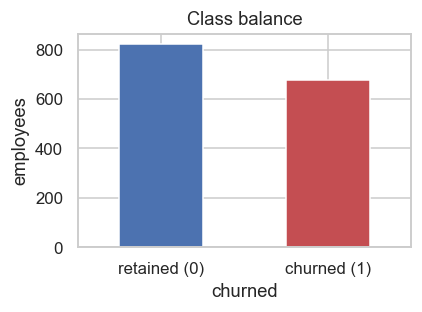

In [3]:
summary = df.describe(include='number').T[['mean', 'std', 'min', 'max']]
display(summary.round(2))

fig, ax = plt.subplots(figsize=(4, 3))
df['churned'].value_counts().sort_index().plot.bar(ax=ax, color=['#4c72b0', '#c44e52'])
ax.set_xticklabels(['retained (0)', 'churned (1)'], rotation=0)
ax.set_title('Class balance'); ax.set_ylabel('employees')
plt.tight_layout(); plt.show()

<a id="quality"></a>
## 2 · Data-quality check

Before trusting any chart, confirm the data is clean: missing values, duplicates, and obviously invalid ranges.

In [4]:
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(),
})
display(quality)
print('duplicate rows:', int(df.duplicated().sum()))
print('negative tenure rows:',
      int((pd.to_datetime(df['last_promotion_date']) < pd.to_datetime(df['hire_date'])).sum()))

,dtype,n_missing,pct_missing,n_unique
employee_id,int64,0,0.000,1500
age,int64,0,0.000,38
gender,object,0,0.000,3
department,object,0,0.000,5
team_id,int64,0,0.000,60
hire_date,datetime64[ns],0,0.000,1192
last_promotion_date,datetime64[ns],0,0.000,48
num_promotions,int64,0,0.000,11
monthly_salary,float64,0,0.000,1496
satisfaction_score,float64,0,0.000,595


duplicate rows: 0
negative tenure rows: 0


**Clean bill of health.** The synthetic generator produces **zero missing values, zero duplicate rows**, and no promotion-before-hire violations — so the rest of the analysis needs no imputation. (Real HRIS extracts are rarely this tidy; the package's `data.clean`/`data.validate` helpers exist precisely to enforce these checks on live data.)

<a id="univariate"></a>
## 3 · Univariate distributions

How is each numeric driver distributed, and does its shape differ between churners and stayers?

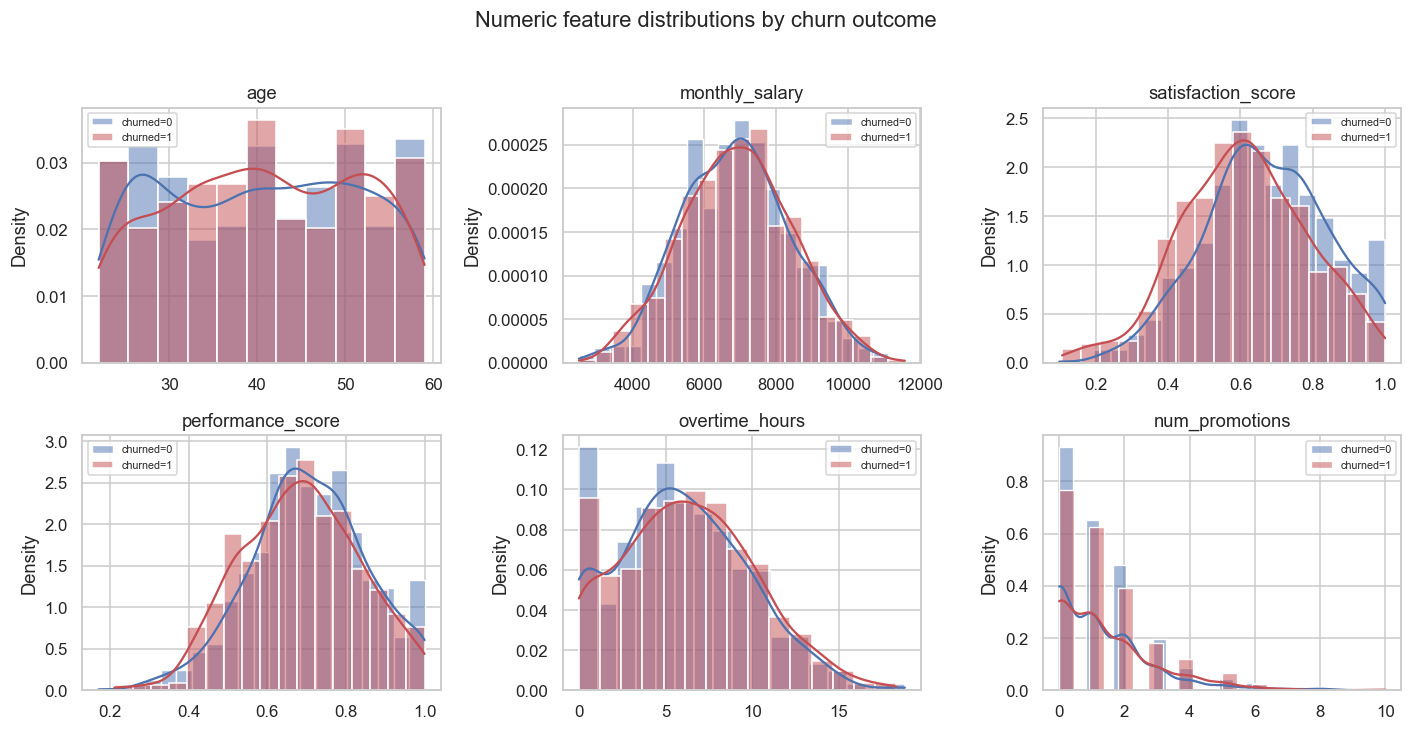

In [5]:
num_cols = ['age', 'monthly_salary', 'satisfaction_score',
            'performance_score', 'overtime_hours', 'num_promotions']
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
for ax, col in zip(axes.ravel(), num_cols):
    for label, color in [(0, '#4c72b0'), (1, '#c44e52')]:
        sns.histplot(df.loc[df['churned'] == label, col], ax=ax, color=color,
                     alpha=0.5, kde=True, stat='density', label=f'churned={label}')
    ax.set_title(col); ax.set_xlabel(''); ax.legend(fontsize=7)
fig.suptitle('Numeric feature distributions by churn outcome', y=1.02)
plt.tight_layout(); plt.show()

**Reading the grid.** Most distributions overlap heavily between the two classes — `age`, `monthly_salary`, `num_promotions`, and `overtime_hours` look nearly identical regardless of outcome. The clearest visible shift is in **`satisfaction_score`**, where churners lean lower, and a milder shift in `performance_score`. We quantify these impressions with hypothesis tests below rather than eyeballing them.

<a id="segments"></a>
## 4 · Churn by department and gender

Breaking churn down by categorical segments reveals only **mild** structural variation.

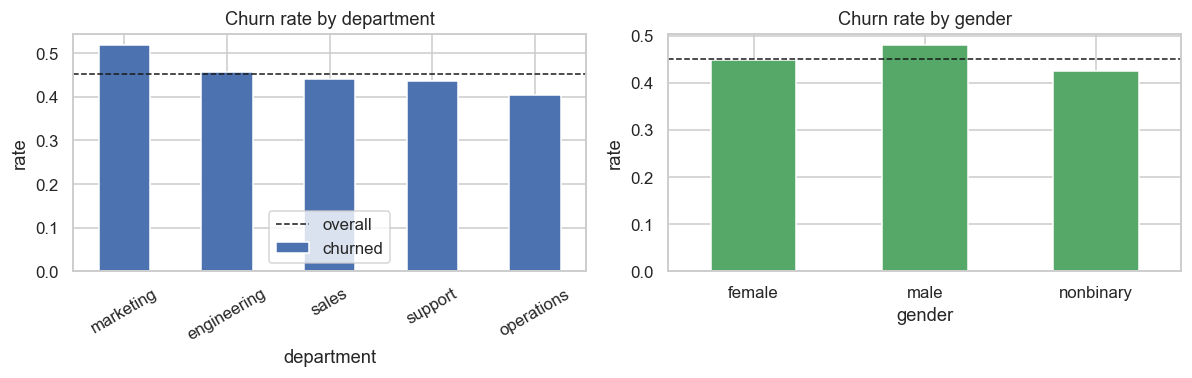

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
(df.groupby('department')['churned'].mean().sort_values(ascending=False)
   .plot.bar(ax=axes[0], color='#4c72b0'))
axes[0].axhline(df['churned'].mean(), ls='--', c='k', lw=1, label='overall')
axes[0].set_title('Churn rate by department'); axes[0].set_ylabel('rate')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=30)
(df.groupby('gender')['churned'].mean()
   .plot.bar(ax=axes[1], color='#55a868'))
axes[1].axhline(df['churned'].mean(), ls='--', c='k', lw=1)
axes[1].set_title('Churn rate by gender'); axes[1].set_ylabel('rate')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

**Reading the charts.** Marketing churns the most (~52%) and operations the least (~40%), but every department sits within ~6 points of the overall 45% line — department alone is a weak predictor. The gender gap is also small in absolute terms (male ~48% vs nonbinary ~43%). Keep that gender spread in mind: it is small here, yet we will see in notebook 04 that the *model* amplifies it into a four-fifths-rule failure.

### Are these differences statistically significant?

Eyeballing rates is not enough. We run **Mann–Whitney U** tests for each numeric feature (churned vs retained distributions) and **chi-square** tests of independence for the categorical segments.

In [7]:
from scipy import stats
num_cols = ['satisfaction_score', 'performance_score', 'overtime_hours',
            'num_promotions', 'age', 'monthly_salary']
ch, rt = df[df['churned'] == 1], df[df['churned'] == 0]
rows = []
for c in num_cols:
    u, p = stats.mannwhitneyu(ch[c], rt[c])
    rows.append({'feature': c, 'p_value': p,
                 'significant_(p<0.05)': p < 0.05})
mw = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
display(mw)
for cat in ['department', 'gender']:
    chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df[cat], df['churned']))
    print(f'chi-square {cat:11s}: p = {p:.4f}'
          f"  ({'significant' if p < 0.05 else 'NOT significant'})")

,feature,p_value,significant_(p<0.05)
0,satisfaction_score,0.000,True
1,performance_score,0.007,True
2,overtime_hours,0.083,False
3,num_promotions,0.159,False
4,age,0.485,False
5,monthly_salary,0.569,False


chi-square department : p = 0.0763  (NOT significant)
chi-square gender     : p = 0.2114  (NOT significant)


**This is a pivotal result.** Only **`satisfaction_score` (p ≈ 0) and `performance_score` (p ≈ 0.007)** differ significantly between churners and stayers; overtime is borderline (p ≈ 0.08) and salary/age/promotions are not significant. Crucially, **neither `department` (p ≈ 0.08) nor `gender` (p ≈ 0.21) is significantly associated with churn.**

Hold onto the gender result: in the data, gender carries *no* statistically detectable churn signal — yet notebook 04 shows the trained model still flags genders at materially different rates. That gap between *data* and *model* behaviour is exactly why a dedicated fairness audit is non-negotiable.

<a id="correlation"></a>
## 5 · Correlation structure

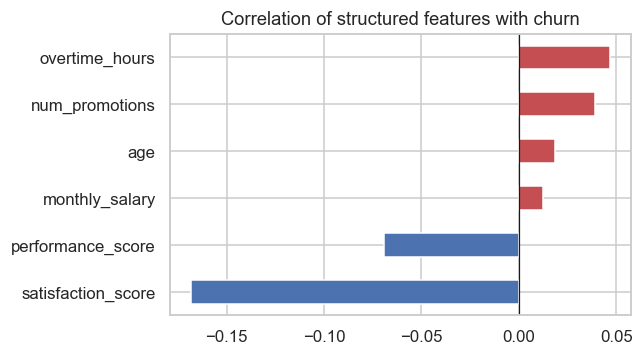

satisfaction_score   -0.168
performance_score    -0.069
monthly_salary        0.012
age                   0.019
num_promotions        0.039
overtime_hours        0.047
dtype: float64

In [8]:
num = df.select_dtypes('number').drop(columns=['employee_id', 'team_id'])
corr = num.corrwith(df['churned']).drop('churned').sort_values()
fig, ax = plt.subplots(figsize=(6, 3.4))
corr.plot.barh(ax=ax, color=np.where(corr < 0, '#4c72b0', '#c44e52'))
ax.set_title('Correlation of structured features with churn')
ax.axvline(0, c='k', lw=0.8)
plt.tight_layout(); plt.show()
corr.round(3)

## Structured features carry a weak signal

The strongest structured correlate of churn is **`satisfaction_score` at only −0.17**, followed by `performance_score` (−0.07). Compensation, age, and overtime are essentially flat (|r| < 0.05). No single structured feature is decisive — a linear model on structured data alone would struggle. This is the central motivation for mining the feedback text.

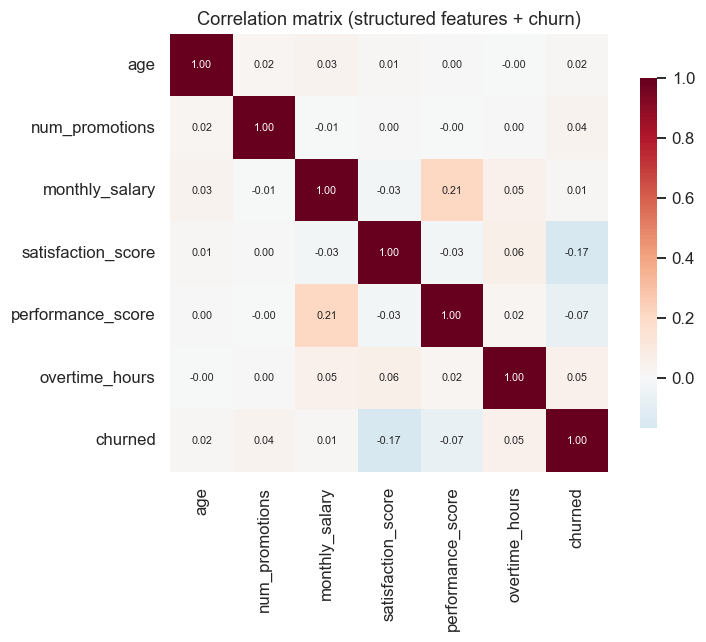

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(num.assign(churned=df['churned']).corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation matrix (structured features + churn)')
plt.tight_layout(); plt.show()

**No multicollinearity surprises.** The off-diagonal correlations are all near zero, so the structured features are largely independent — there is no redundant pair to prune, but also no structured feature combination that obviously interacts. The `churned` row/column is pale across the board, visually reinforcing that the structured block is a weak predictor set on its own.

<a id="tenure"></a>
## 6 · Tenure dynamics

Churn risk is often highly non-linear in tenure, which is why the package buckets it into ordinal bands. Does risk vary across the career stage?

,mean,size
tenure_band,,
1-3y,0.442,52
3-7y,0.433,934
7y+,0.486,514


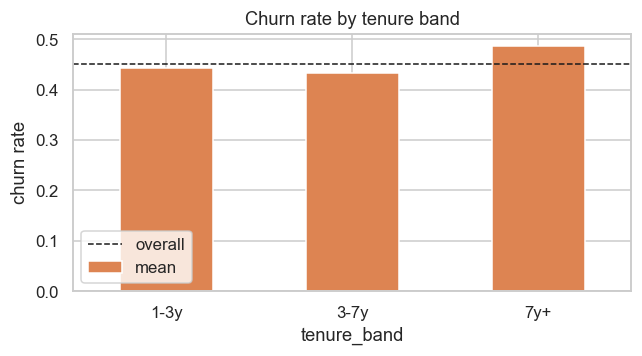

In [10]:
from employee_churn.features.engineer_structured import (
    add_career_progression_features, add_tenure_bands)
tf = add_career_progression_features(df, 'hire_date', 'last_promotion_date')
tf = add_tenure_bands(tf)
band = tf.groupby('tenure_band', observed=True)['churned'].agg(['mean', 'size'])
display(band.round(3))

fig, ax = plt.subplots(figsize=(6, 3.4))
band['mean'].plot.bar(ax=ax, color='#dd8452')
ax.axhline(df['churned'].mean(), ls='--', c='k', lw=1, label='overall')
ax.set_title('Churn rate by tenure band'); ax.set_ylabel('churn rate')
ax.tick_params(axis='x', rotation=0); ax.legend()
plt.tight_layout(); plt.show()

**A gentle senior-tenure uptick.** Risk is essentially flat for the 1–3y and 3–7y bands (~0.44) and rises modestly for **7y+ employees (~0.49)** — consistent with long-tenure staff who have stagnated (note `days_since_promotion` was the strongest *structured* model feature in notebook 03). The effect is real but small; tenure alone will not carry a model.

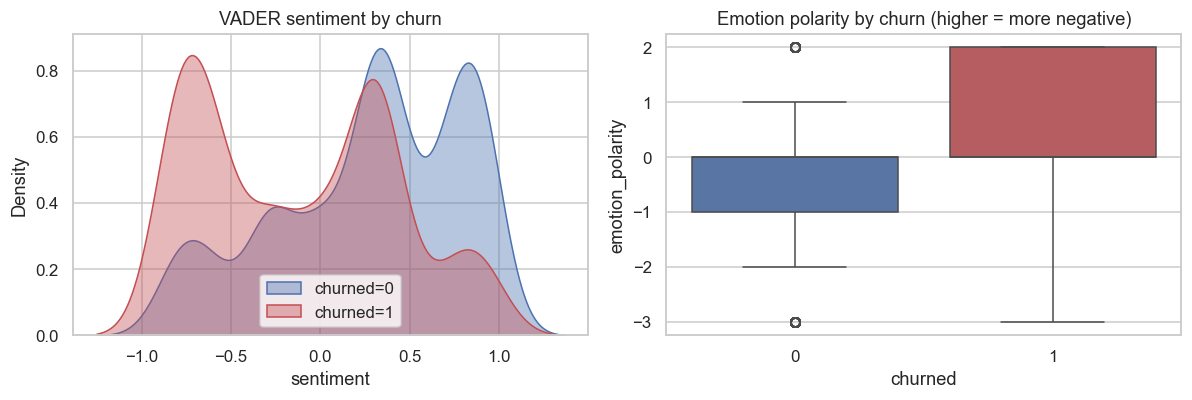

mean sentiment    {0: 0.272, 1: -0.121}
mean emo polarity {0: -0.574, 1: 0.425}


In [11]:
from employee_churn.nlp.sentiment import add_sentiment_scores
from employee_churn.nlp.emotion import add_emotion_features
t = add_sentiment_scores(df, 'feedback')
t = add_emotion_features(t, 'feedback')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for label, color in [(0, '#4c72b0'), (1, '#c44e52')]:
    sns.kdeplot(t.loc[t['churned'] == label, 'sentiment'], ax=axes[0],
                fill=True, alpha=0.4, color=color, label=f'churned={label}')
axes[0].set_title('VADER sentiment by churn'); axes[0].legend()
sns.boxplot(data=t, x='churned', y='emotion_polarity', ax=axes[1],
            palette=['#4c72b0', '#c44e52'])
axes[1].set_title('Emotion polarity by churn (higher = more negative)')
plt.tight_layout(); plt.show()

print('mean sentiment   ', t.groupby('churned')['sentiment'].mean().round(3).to_dict())
print('mean emo polarity', t.groupby('churned')['emotion_polarity'].mean().round(3).to_dict())

<a id="text"></a>
## 7 · The text tells the story

Now the signal is obvious. **Retained employees average a clearly positive sentiment (~+0.27) while churners average negative (~−0.12)** — the two distributions visibly separate. The lexicon-based `emotion_polarity` (negative-emotion hits minus positive ones) flips sign across the two groups: churners skew positive (more fear/anger/sadness words), retained employees skew negative (more joy/trust words).

Even with the lightweight VADER + lexicon approach, the feedback text separates the classes far better than any structured column. That is the thesis the modeling notebook will confirm quantitatively.

### Which words distinguish the two groups?

Using the package's `nlp.preprocessing` pipeline (clean → tokenize → stopword removal), we count the most frequent content words in each group's feedback.

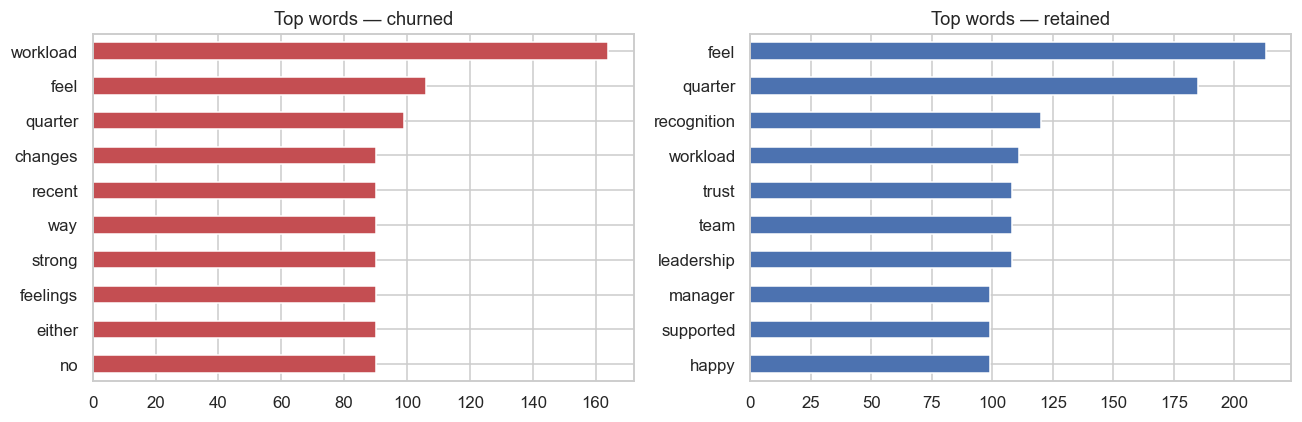

In [12]:
from collections import Counter
from employee_churn.nlp.preprocessing import preprocess

def top_words(texts, n=10):
    counter = Counter()
    for txt in texts:
        counter.update(preprocess(txt))
    return pd.Series(dict(counter.most_common(n)))

churn_words = top_words(df.loc[df['churned'] == 1, 'feedback'])
stay_words = top_words(df.loc[df['churned'] == 0, 'feedback'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
churn_words.sort_values().plot.barh(ax=axes[0], color='#c44e52')
axes[0].set_title('Top words — churned')
stay_words.sort_values().plot.barh(ax=axes[1], color='#4c72b0')
axes[1].set_title('Top words — retained')
plt.tight_layout(); plt.show()

**The vocabulary splits cleanly.** Churners' feedback is dominated by `workload`, hedging/neutral language (`no`, `strong`, `feelings`, `either`, `way` — the 'no strong feelings either way' register of disengagement), while retained employees write about `recognition`, `trust`, `leadership`, `team`, and `happy`. The presence of explicitly positive relational words on the retained side — and their near-absence on the churn side — is exactly the signal VADER and the emotion lexicon pick up. A future transformer-based encoder (on the roadmap) would capture this even more richly.

<a id="takeaways"></a>
## Takeaways

1. **Data is clean** (no missing/duplicate/invalid rows) and the target is ~balanced (45% churn) — use AUC/F1/precision@k, not accuracy.
2. Only **`satisfaction_score` and `performance_score`** are statistically significant structured drivers; salary, age, promotions, department, and **gender are not** (chi-square p ≈ 0.21).
3. Structured features are individually weak (best |r| ≈ 0.17) and mutually uncorrelated — no single one is decisive.
4. **Text-derived sentiment, emotion, and vocabulary are the strongest separators** — the modeling notebook should (and does) weight them heavily.
5. Gender shows **no significant raw association** with churn, so any model-level gender disparity is model-induced — audited in notebook 04.